# Mini-Project: Speech Emotion Classification
## Prashanth Kannadaguli
### Senior Data Science Trainer

## Problem Statement

Build a model to recognize emotion from speech using Ensemble learning

## Learning Objectives

At the end of the mini-project, you will be able to :

* extract the features from audio data
* implement ML classification algorithms individually and as Ensembles, to classify emotions
* record the voice sample and test it with trained model

## Dataset

**TESS Dataset**

The first dataset chosen for this mini-project is the [TESS](https://dataverse.scholarsportal.info/dataset.xhtml?persistentId=doi:10.5683/SP2/E8H2MF) (Toronto emotional speech set) dataset. It contains 2880 files.  A set of 200 target words were spoken in the carrier phrase "Say the word _____' by two actresses and the sets were recorded in seven different emotions (anger, disgust, fear, happiness, pleasant surprise, sadness, and neutral). Both actresses spoke English as their first language, were university educated, and had musical training. Audiometric testing indicated that both actresses had thresholds within the normal range.

**Ravdess Dataset**

The second dataset chosen for this mini-project is [Ravdess](https://zenodo.org/record/1188976#.YLczy4XivIU) (The Ryerson Audio-Visual Database of Emotional Speech and Song). This dataset contains 1440 files: 60 trials per actor x 24 actors = 1440. The RAVDESS contains 24 professional actors (12 female, 12 male), vocalizing two lexically-matched statements in a neutral North American accent. Speech emotions includes calm, happy, sad, angry, fearful, surprise, and disgust expressions. Each expression is produced at two levels of emotional intensity (normal, strong), with an additional neutral expression.

**File naming convention**

Each of the 1440 files has a unique filename. The filename consists of a 7-part numerical identifier (e.g., 03-01-06-01-02-01-12.wav). These identifiers define the stimulus characteristics:

**Filename identifiers**

* Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
* Vocal channel (01 = speech, 02 = song).
* Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
* Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
* Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
* Repetition (01 = 1st repetition, 02 = 2nd repetition).
* Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

Filename example: `03-01-06-01-02-01-12.wav`

    - Audio-only - 03
    - Speech - 01
    - Fearful - 06
    - Normal intensity - 01
    - Statement "dogs" - 02
    - 1st Repetition - 01
    - 12th Actor - 12 Female, as the actor ID number is even.

## Information

**Speech Emotion Recognition (SER)** is the task of recognizing the emotion from  speech, irrespective of the semantics. Humans can efficiently perform this task as a natural part of speech communication, however, the ability to conduct it automatically using programmable devices is a field of active research.

Studies of automatic emotion recognition systems aim to create efficient, real-time methods of detecting the emotions of mobile phone users, call center operators and customers, car drivers, pilots, and many other human-machine communication users. Adding emotions to machines forms an important aspect of making machines appear and act in a human-like manner

Lets gain familiarity with some of the audio based features that are commonly used for SER.

**Mel scale** — The mel scale (derived from the word *melody*) is a perceptual scale of pitches judged by listeners to be equal in distance from one another. The reference point between this scale and normal frequency measurement is defined by assigning a perceptual pitch of 1000 mels to a 1000 Hz tone, 40 dB above the listener's threshold. Above about 500 Hz, increasingly large intervals are judged by listeners to produce equal pitch increments. Refer [here](https://towardsdatascience.com/learning-from-audio-the-mel-scale-mel-spectrograms-and-mel-frequency-cepstral-coefficients-f5752b6324a8) for more detailed information.

**Pitch** — how high or low a sound is. It depends on frequency, higher pitch is high frequency

**Frequency** — speed of vibration of sound, measures wave cycles per second

**Chroma** — Representation for audio where spectrum is projected onto 12 bins representing the 12 distinct semitones (or chroma). Computed by summing the log frequency magnitude spectrum across octaves.

**Fourier Transforms** — used to convert from time domain to frequency domain. Time domain shows how signal changes over time. Frequency domain shows how much of the signal lies within each given frequency band over a range of frequencies

**Librosa**

[Librosa](https://librosa.org/doc/latest/index.html) is a Python package, built for speech and audio analytics. It provides modular functions that simplify working with audio data and help in achieving a wide range of applications such as identification of the personal characteristics of different individuals' voice samples, detecting emotions from audio samples etc.

For further details on the Librosa package, refer [here](https://conference.scipy.org/proceedings/scipy2015/pdfs/brian_mcfee.pdf).


### Download and unzip dataset from https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Ravdess_Tess.zip

In [1]:
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Ravdess_Tess.zip
!unzip -qq Ravdess_Tess.zip

!pip install -qq librosa soundfile wavio --break-system-packages

fish: Unknown command: zoxide
~/.config/fish/config.fish (line 1): 
zoxide init fish | source
^~~~~^
from sourcing file ~/.config/fish/config.fish
	called during startup
fish: Unknown command: starship
~/.config/fish/config.fish (line 2): 
starship init fish | source
^~~~~~~^
from sourcing file ~/.config/fish/config.fish
	called during startup
fish: Unknown command: atuin
~/.config/fish/config.fish (line 3): 
atuin init fish | source
^~~~^
from sourcing file ~/.config/fish/config.fish
	called during startup
fish: Unknown command: zoxide
~/.config/fish/config.fish (line 1): 
zoxide init fish | source
^~~~~^
from sourcing file ~/.config/fish/config.fish
	called during startup
fish: Unknown command: starship
~/.config/fish/config.fish (line 2): 
starship init fish | source
^~~~~~~^
from sourcing file ~/.config/fish/config.fish
	called during startup
fish: Unknown command: atuin
~/.config/fish/config.fish (line 3): 
atuin init fish | source
^~~~^
from sourcing file ~/.config/fish/config.fi

### Import Neccesary Packages

In [2]:
import os
import glob
import librosa
import librosa.display
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

ModuleNotFoundError: No module named 'matplotlib'

### Work-Flow

* Load the TESS audio data and extract features and labels

* Load the Ravdess audio data and extract features

* Combine both the audio dataset features

* Train and test the model with TESS + Ravdess Data

* Record the team audio samples and add them to TESS + Ravdess data

* Train and test the model with TESS + Ravdess + Team Recorded (combined) data

* Test each of the models with live audio sample recording.

### Load the Tess data and Ravdess data audio files

Hint: `glob.glob`

In [3]:
# Load file paths using glob
tess_files = glob.glob('TESS/*/*.wav') if os.path.exists('TESS') else glob.glob('*TESS*/*/*.wav')
ravdess_files = glob.glob('Ravdess/*/*.wav') if os.path.exists('Ravdess') else glob.glob('*Ravdess*/*/*.wav')

# Fallback recursive search if directory structure varies
if len(tess_files) == 0:
    tess_files = [f for f in glob.glob('**/*.wav', recursive=True) if 'tess' in f.lower()]
if len(ravdess_files) == 0:
    ravdess_files = [f for f in glob.glob('**/*.wav', recursive=True) if 'ravdess' in f.lower() or 'actor' in f.lower()]

print("Length of Tess =", len(tess_files))
print("Length of Ravdess =", len(ravdess_files))

Length of Tess = 2679
Length of Ravdess = 1168


#### Play the sample audio

In [4]:
# Play a sample TESS audio file
if len(tess_files) > 0:
    sample_file = tess_files[0]
    print(f"Playing sample file: {sample_file}")
    ipd.display(ipd.Audio(sample_file))

Playing sample file: Tess/OAF_Fear/OAF_back_fear.wav


### Data Exploration and Visualization

#### Visualize the distribution of all the labels

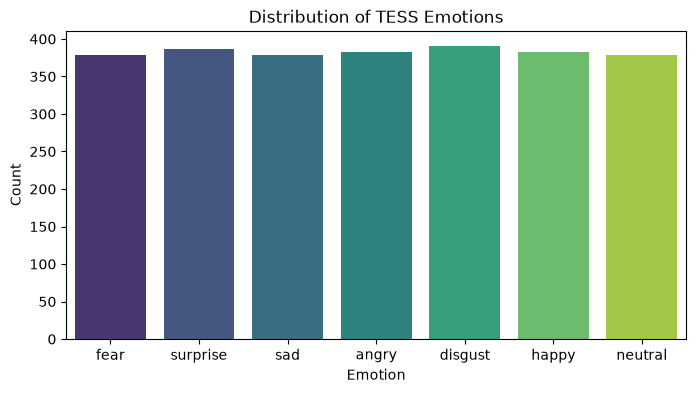

In [5]:
# Parse emotions from filenames
def get_tess_emotion(path):
    filename = os.path.basename(path).lower()
    if 'angry' in filename or 'anger' in filename: return 'angry'
    if 'disgust' in filename: return 'disgust'
    if 'fear' in filename: return 'fear'
    if 'happy' in filename or 'happiness' in filename: return 'happy'
    if 'neutral' in filename: return 'neutral'
    if 'ps' in filename or 'surprise' in filename: return 'surprise'
    if 'sad' in filename or 'sadness' in filename: return 'sad'
    return 'unknown'

tess_emotions = [get_tess_emotion(f) for f in tess_files]

plt.figure(figsize=(8, 4))
sns.countplot(x=tess_emotions, hue=tess_emotions, palette='viridis', legend=False)
plt.title('Distribution of TESS Emotions')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show()

#### Visualize sample audio signal using librosa

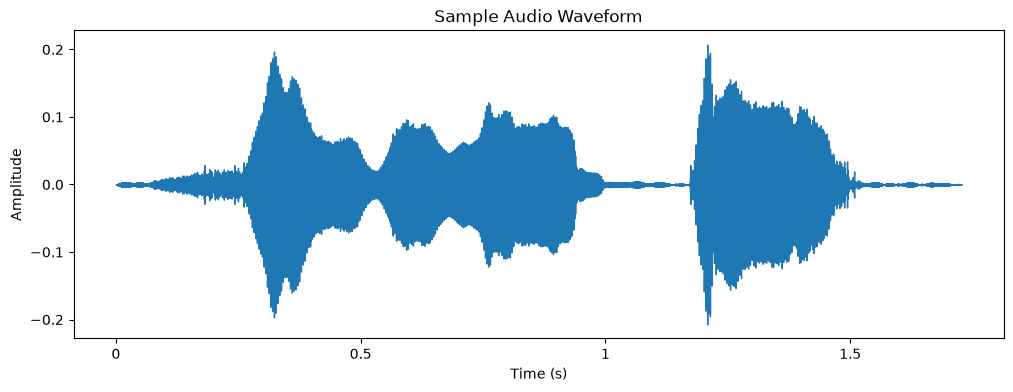

In [6]:
if len(tess_files) > 0:
    data, sr = librosa.load(tess_files[0])
    
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(data, sr=sr)
    plt.title('Sample Audio Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.show()

### Feature extraction

Read one WAV file at a time using `Librosa`. An audio time series in the form of a 1-dimensional array for mono or 2-dimensional array for stereo, along with time sampling rate (which defines the length of the array), where the elements within each of the arrays represent the amplitude of the sound waves is returned by `librosa.load()` function. Refer to the supplementary notebook ('Audio feature extraction')

To know more about Librosa, explore the [link](https://librosa.org/doc/latest/feature.html)

In [8]:
def extract_features(file_path):
    data, sample_rate = librosa.load(file_path, duration=2.5, offset=0.6)
    
    # 1. MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=40).T, axis=0)
    
    # 2. Chroma
    stft = np.abs(librosa.stft(data))
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    
    # 3. Mel Spectrogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    
    return np.hstack([mfcc, chroma, mel])

# --- Demonstration & Output Display ---
if len(tess_files) > 0:
    sample_file = tess_files[0]
    
    # Play sample audio
    print(f"🔊 Playing Audio Sample: {os.path.basename(sample_file)}")
    ipd.display(ipd.Audio(sample_file))
    
    # Extract features
    sample_features = extract_features(sample_file)
    
    print("\n--- Feature Extraction Output Summary ---")
    print(f"Total Feature Vector Length: {len(sample_features)} values")
    print(f"  • MFCC features count:  40")
    print(f"  • Chroma features count: 12")
    print(f"  • Mel Spectrogram count: 128")
    
    # Display first 10 feature values
    df_sample = pd.DataFrame([sample_features[:10]], columns=[f"Feature_{i+1}" for i in range(10)])
    print("\nFirst 10 Extracted Feature Values:")
    ipd.display(df_sample)

🔊 Playing Audio Sample: OAF_back_fear.wav



--- Feature Extraction Output Summary ---
Total Feature Vector Length: 180 values
  • MFCC features count:  40
  • Chroma features count: 12
  • Mel Spectrogram count: 128

First 10 Extracted Feature Values:


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
0,-450.097656,91.425529,-2.860072,-17.648521,4.165442,4.095837,-12.731226,-0.076303,-7.467885,2.455537


#### Create a dictionary or a function to encode the emotions

In [ ]:
# RAVDESS emotion mapping based on standard identifier index (01 to 08)
ravdess_emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': 'disgust',
    '08': 'surprise'
}

def parse_ravdess_emotion(file_path):
    filename = os.path.basename(file_path)
    parts = filename.split('-')
    if len(parts) >= 3:
        return ravdess_emotion_map.get(parts[2], 'unknown')
    return 'unknown'

#### TESS data feature extraction

In [10]:
tess_features = []
tess_labels = []

for file in tess_files:
    emotion = get_tess_emotion(file)
    if emotion != 'unknown':
        feat = extract_features(file)
        tess_features.append(feat)
        tess_labels.append(emotion)

print(f"Extracted {len(tess_features)} TESS samples.")


Extracted 2679 TESS samples.


#### Ravdess data feature extraction

In [11]:
ravdess_features = []
ravdess_labels = []

for file in ravdess_files:
    emotion = parse_ravdess_emotion(file)
    if emotion != 'unknown':
        feat = extract_features(file)
        ravdess_features.append(feat)
        ravdess_labels.append(emotion)

print(f"Extracted {len(ravdess_features)} RAVDESS samples.")

Extracted 1168 RAVDESS samples.


#### Save the features

It is best advised to save the features in dataframe and maintain so that feature extraction step is not required to be performed every time.

* Make a DataFrame with features and labels

* Write dataframe into `.CSV` file and save it offline.

In [12]:
# Combine features and labels
X_combined = np.vstack([tess_features, ravdess_features]) if len(ravdess_features) > 0 else np.array(tess_features)
y_combined = np.array(tess_labels + ravdess_labels)

# Convert to DataFrame
df_features = pd.DataFrame(X_combined)
df_features['label'] = y_combined

# Save to CSV
df_features.to_csv('combined_speech_features.csv', index=False)
print("Features saved to combined_speech_features.csv successfully!")

Features saved to combined_speech_features.csv successfully!


#### Split the data into train and test

In [13]:
X = df_features.drop(columns=['label']).values
y = df_features['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3077, 180)
X_test shape: (770, 180)


### Train the model with TESS + Ravdess data

* Apply DecisionTree and find clasification report, confusion matrix, AUC-ROC curve

--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.73      0.72      0.73       112
     disgust       0.66      0.72      0.69       114
        fear       0.69      0.72      0.71       112
       happy       0.70      0.62      0.66       112
     neutral       0.89      0.87      0.88        93
         sad       0.81      0.75      0.78       113
    surprise       0.62      0.68      0.65       114

    accuracy                           0.72       770
   macro avg       0.73      0.73      0.73       770
weighted avg       0.73      0.72      0.72       770


--- Confusion Matrix ---


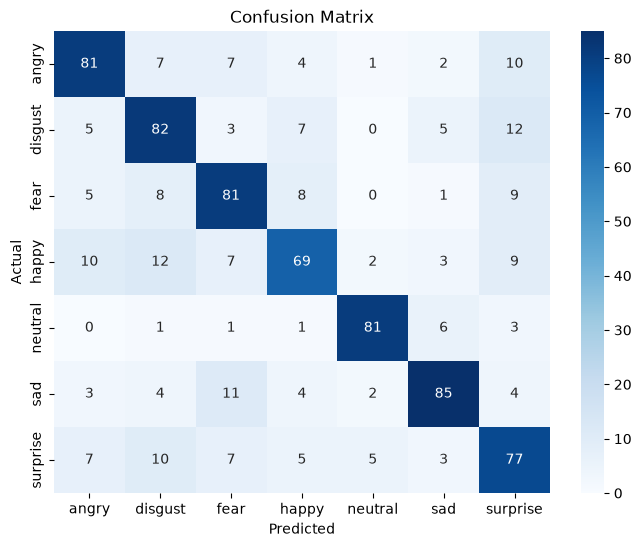


Macro AUC-ROC Score: 0.8397


In [14]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)

# Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y), cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Multiclass AUC-ROC Score
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
y_pred_bin = lb.transform(y_pred)

auc_roc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print(f"\nMacro AUC-ROC Score: {auc_roc:.4f}")